# Quick start tutorial

This tutorial only shows the most basic use case on 2D images.

Let us first create a dense deformation and an affine transformation and then compose them.

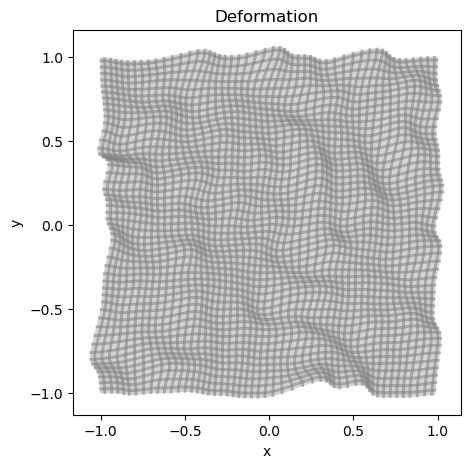

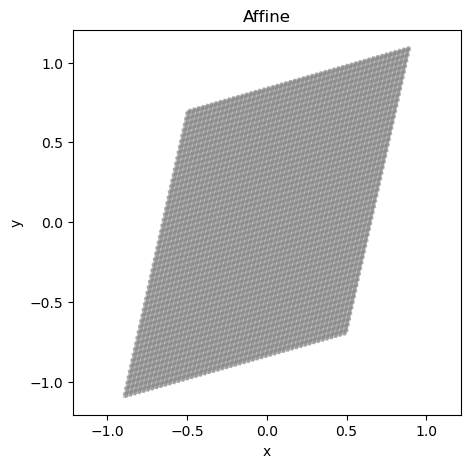

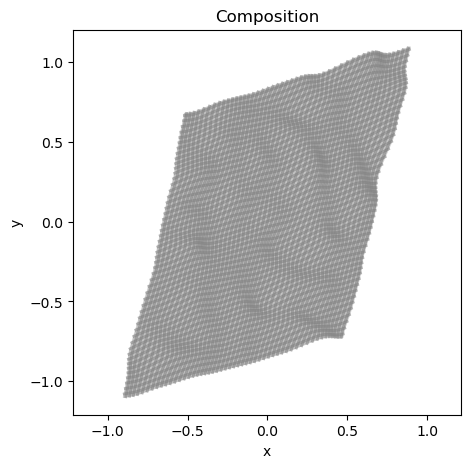

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from scipy import ndimage

import torchmorph as tm

np.random.seed(42)

centered_normalized_coordinate_factory = tm.CoordinateSystemFactory.centered_normalized()
deformation = tm.samplable_volume(
    torch.from_numpy(
        np.stack(
            [
                ndimage.gaussian_filter(
                    80 * np.random.randn(2, 256, 256).astype("float32"), sigma=9.0
                ),
                ndimage.gaussian_filter(
                    80 * np.random.randn(2, 256, 256).astype("float32"), sigma=9.0
                ),
            ],
            axis=0,
        )
    ),
    coordinate_system=centered_normalized_coordinate_factory,
    data_format=tm.DataFormat.voxel_displacements(),
)
affine = tm.affine(torch.tensor([[0.7, 0.2, 0.0], [0.2, 0.9, 0.0], [0.0, 0.0, 1.0]]))
composition = deformation @ affine
tm.visualize_as_deformed_grid(deformation)
plt.title("Deformation")
plt.show()
tm.visualize_to_as_deformed_grid(affine, target=deformation.coordinate_system)
plt.title("Affine")
plt.show()
tm.visualize_as_deformed_grid(composition)
plt.title("Composition")
plt.show()

Let us apply the composed deformation to an image and visualize the image. The mask of extrapolated regions (shown in red) is automatically generated which can then be used e.g. in loss functions.

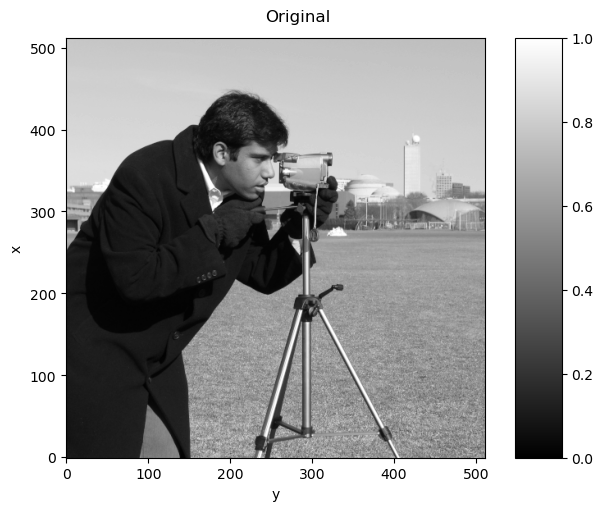

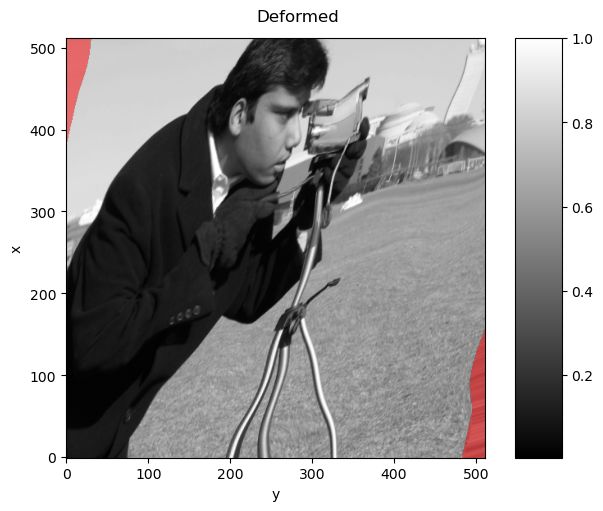

In [2]:
from matplotlib.image import imread

image_data = torch.from_numpy(imread("../tutorials/camera.png"))[None, None]
image = tm.samplable_volume(
    image_data,
    coordinate_system=centered_normalized_coordinate_factory,
)
deformed_image = image @ composition

# We flip the coordinates for visualization for the image to show correct size up
visualization_coordinates = image.coordinate_system.transform_world_with_diagonal_matrix(
    torch.tensor([-1.0, 1.0])
)
fig = tm.visualize_to_as_image(image, target=visualization_coordinates)
fig.suptitle("Original")
plt.show()
fig = tm.visualize_to_as_image(deformed_image, target=visualization_coordinates)
fig.suptitle("Deformed")
plt.show()

One can also invert the deformation (via fixed point iteration, differentiable via implicit differentation):

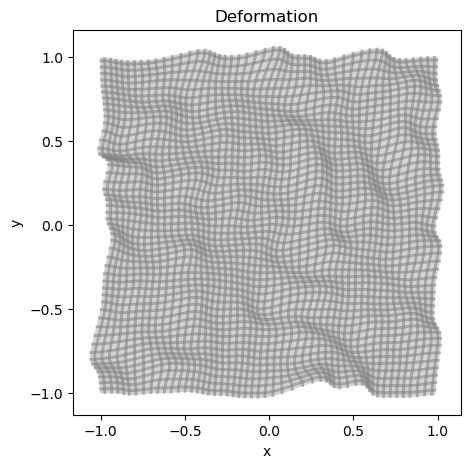

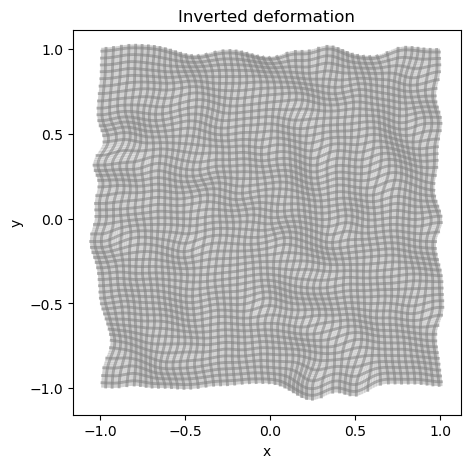

In [3]:
inverted_deformation = deformation.invert()
tm.visualize_as_deformed_grid(deformation)
plt.title("Deformation")
plt.show()
tm.visualize_as_deformed_grid(inverted_deformation)
plt.title("Inverted deformation")
plt.show()